<a href="https://colab.research.google.com/github/klitsadaphongth68-dev/Toxic-Comments-Dataset/blob/main/%E0%B9%82%E0%B8%84%E0%B8%A3%E0%B8%87%E0%B8%87%E0%B8%B2%E0%B8%99%E0%B8%84%E0%B8%A7%E0%B8%B2%E0%B8%A1%E0%B8%84%E0%B8%B4%E0%B8%94%E0%B9%80%E0%B8%AB%E0%B9%87%E0%B8%99%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B8%84%E0%B8%A7%E0%B8%B2%E0%B8%A1%E0%B9%80%E0%B8%9B%E0%B9%87%E0%B8%99%E0%B8%9E%E0%B8%B4%E0%B8%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 15-EDA: โครงงานวิเคราะห์ความคิดเห็นและระดับความเป็นพิษของคอมเมนต์

> ปรับโครงสร้างตาม Lab 15: Data Understanding → Visualization → Deep EDA → Hypothesis Testing → Problem Framing → Model Selection  
> **โจทย์และ Dataset เดิมของโครงงาน**: Toxic Comments Dataset จำนวน 30,000 รายการ

## 👥 สมาชิกในกลุ่ม

| ลำดับ | ชื่อ-นามสกุล | รหัสนักศึกษา |
|---|---|---|
| 1 | นาย ณัฐนน กรุณา | 68114540782 |
| 2 | นาย กฤษฎาพงษ์ ทิณพัฒน์ | 6811540054 |

## คำถามการวิจัย (Research Questions)
1. `Toxicity_Score` มีความสัมพันธ์กับ `Comment_Length` และ `Word_Count` หรือไม่?
2. ระดับความเป็นพิษแตกต่างกันตาม `Platform`, `Topic` และ `Toxicity_Label` หรือไม่?
3. การกระจายตัวของ `Toxicity_Score` เป็นอย่างไร และมี Outliers ตามเกณฑ์ IQR หรือไม่?

## Setup: ติดตั้งและ Import Libraries

ส่วนนี้ใช้โครงสร้างเดียวกับ Lab 15 แต่เพิ่มเครื่องมือที่จำเป็นสำหรับ Dataset นี้ เช่น การทำ One-Hot Encoding, Multiclass Classification และการประเมินโมเดล

In [ ]:
# ─── ติดตั้ง packages ที่อาจไม่มีใน environment ───────────────────────
!pip install -q statsmodels scikit-learn seaborn pandas numpy scipy

In [ ]:
# ─── Import: Data handling ─────────────────────────────────────────────
import os
import zipfile
import numpy as np
import pandas as pd

# ─── Import: Visualization ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Import: Statistics ─────────────────────────────────────────────────
from scipy import stats
from scipy.stats import chi2_contingency, kruskal

# ─── Import: Machine Learning ───────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

---
## Part 0: โหลดข้อมูล — Toxic Comments Dataset

ใช้ **Dataset เดิมของโครงงาน** ไม่เปลี่ยนโจทย์หรือข้อมูล โดยรองรับไฟล์ `archive.zip` ที่ภายในมี `toxic_comments_dataset.csv`

In [ ]:
# ─── โหลดและแตกไฟล์ Dataset สำหรับ Google Colab ────────────────────────
zip_file = "archive.zip"
extract_folder = "dataset"

if not os.path.exists(zip_file):
    try:
        from google.colab import files
        uploaded = files.upload()
    except ImportError:
        print("กรุณาวาง archive.zip ไว้ใน working directory")

if os.path.exists(zip_file):
    os.makedirs(extract_folder, exist_ok=True)
    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall(extract_folder)

csv_candidates = []
for root, dirs, files_ in os.walk(extract_folder):
    for f in files_:
        if f.lower() == "toxic_comments_dataset.csv":
            csv_candidates.append(os.path.join(root, f))

if not csv_candidates and os.path.exists("toxic_comments_dataset.csv"):
    csv_candidates = ["toxic_comments_dataset.csv"]

if not csv_candidates:
    raise FileNotFoundError("ไม่พบ toxic_comments_dataset.csv กรุณาตรวจสอบ archive.zip")

dataset_path = csv_candidates[0]
print("Dataset path:", dataset_path)

In [ ]:
# ─── มองภาพรวมแรก: คอลัมน์ทั้งหมดและความหมาย ─────────────────────────
df = pd.read_csv(dataset_path)

column_meaning = {
    "Comment_ID": "รหัสความคิดเห็น",
    "Toxicity_Label": "ประเภท/ระดับความเป็นพิษของความคิดเห็น (5 กลุ่ม)",
    "Toxicity_Score": "คะแนนความเป็นพิษ 0–1",
    "Comment_Length": "ความยาวความคิดเห็นในหน่วยตัวอักษร",
    "Word_Count": "จำนวนคำในความคิดเห็น",
    "Platform": "แหล่งที่มาของความคิดเห็น",
    "Topic": "หัวข้อของความคิดเห็น",
    "Moderation_Priority": "ระดับความสำคัญในการตรวจสอบ",
    "Language": "ภาษา"
}

print("Shape:", df.shape)
display(pd.DataFrame({
    "Column": df.columns,
    "Meaning": [column_meaning.get(c, "ไม่มีคำอธิบายในโครงงานเดิม") for c in df.columns]
}))
display(df.head())

Shape: (30000, 15)


,Column,Meaning
0,Comment_ID,รหัสความคิดเห็น
1,Comment_Text,ไม่มีคำอธิบายในโครงงานเดิม
2,Toxicity_Label,ประเภท/ระดับความเป็นพิษของความคิดเห็น (5 กลุ่ม)
3,Clean,ไม่มีคำอธิบายในโครงงานเดิม
4,Toxic,ไม่มีคำอธิบายในโครงงานเดิม
5,Severe_Toxic,ไม่มีคำอธิบายในโครงงานเดิม
6,Threat,ไม่มีคำอธิบายในโครงงานเดิม
7,Identity_Attack,ไม่มีคำอธิบายในโครงงานเดิม
8,Toxicity_Score,คะแนนความเป็นพิษ 0–1
9,Comment_Length,ความยาวความคิดเห็นในหน่วยตัวอักษร


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English


---
## Part 1: Data Understanding — ทำความเข้าใจโครงสร้างข้อมูล

**หลักการเดียวกับ Lab 15:** ต้องเข้าใจ shape, data types, missing values, duplicates และ cardinality ก่อนทำ EDA หรือสร้างโมเดล

### 1.1 โครงสร้างพื้นฐาน: Shape, Data Types, Memory

In [ ]:
# ─── ตรวจสอบ dtypes และ memory usage ─────────────────────────────────
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Memory Usage ===")
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

=== Shape ===
(30000, 15)

=== Data Types ===
Comment_ID              object
Comment_Text            object
Toxicity_Label          object
Clean                    int64
Toxic                    int64
Severe_Toxic             int64
Threat                   int64
Identity_Attack          int64
Toxicity_Score         float64
Comment_Length           int64
Word_Count               int64
Platform                object
Topic                   object
Moderation_Priority     object
Language                object
dtype: object

=== Memory Usage ===
14.532567024230957 MB


### 1.2 Missing Values — ต้องรู้ก่อนทำอะไรทั้งหมด

ตรวจทั้งจำนวนและสัดส่วน Missing Values เพื่อใช้ตัดสินใจใน preprocessing

In [ ]:
# ─── นับ missing values ทุกคอลัมน์ ────────────────────────────────────
missing = pd.DataFrame({
    "จำนวน_missing": df.isnull().sum(),
    "เปอร์เซ็นต์": (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing.sort_values("จำนวน_missing", ascending=False))

,จำนวน_missing,เปอร์เซ็นต์
Comment_ID,0,0.0
Comment_Text,0,0.0
Toxicity_Label,0,0.0
Clean,0,0.0
Toxic,0,0.0
Severe_Toxic,0,0.0
Threat,0,0.0
Identity_Attack,0,0.0
Toxicity_Score,0,0.0
Comment_Length,0,0.0


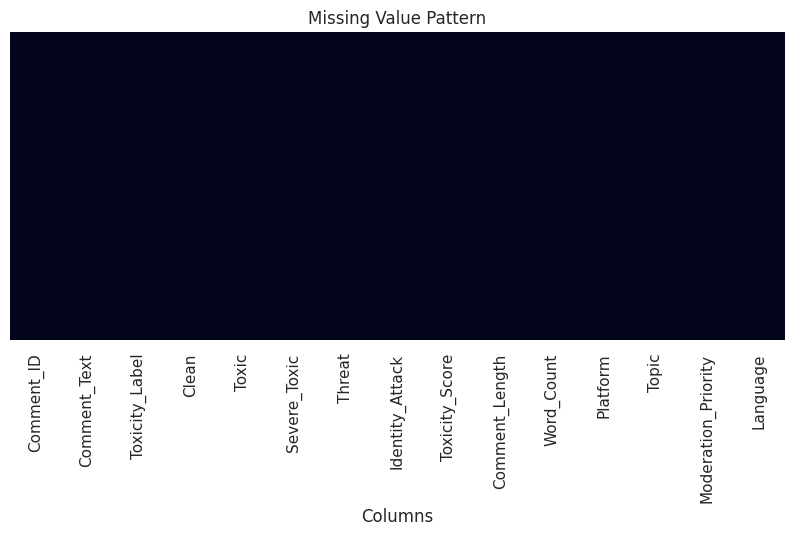

In [ ]:
# ─── Visualize Missing Value Pattern ──────────────────────────────────
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Pattern")
plt.xlabel("Columns")
plt.show()

### 1.3 Duplicates และ Cardinality ของ Categorical Variables

In [ ]:
# ─── ตรวจสอบแถวซ้ำและจำนวน category ───────────────────────────────────
n_dup = df.duplicated().sum()
n_id_dup = df["Comment_ID"].duplicated().sum()

print(f"Duplicate rows: {n_dup} จาก {len(df)} แถว ({n_dup/len(df)*100:.2f}%)")
print(f"Duplicate Comment_ID: {n_id_dup}")

cat_cols = ["Toxicity_Label", "Platform", "Topic", "Moderation_Priority", "Language"]
cardinality = pd.DataFrame({
    "n_unique": [df[c].nunique(dropna=True) for c in cat_cols],
    "missing": [df[c].isnull().sum() for c in cat_cols]
}, index=cat_cols)
display(cardinality)

for col in cat_cols:
    print(f"\n===== {col} =====")
    display(df[col].value_counts(dropna=False))

Duplicate rows: 0 จาก 30000 แถว (0.00%)
Duplicate Comment_ID: 0


,n_unique,missing
Toxicity_Label,5,0
Platform,5,0
Topic,6,0
Moderation_Priority,3,0
Language,1,0



===== Toxicity_Label =====


,count
Toxicity_Label,
Clean,18579
Toxic,6693
Severe_Toxic,1801
Identity_Attack,1468
Threat,1459



===== Platform =====


...

,count
Topic,
Technology,5105
Education,5052
Gaming,5021
Politics,4987
Sports,4964
Entertainment,4871



===== Moderation_Priority =====


,count
Moderation_Priority,
Medium,10090
High,10013
Low,9897



===== Language =====


,count
Language,
English,30000


**Insight จาก Part 1:** บันทึกผลที่พบจากข้อมูลจริง เช่น missing values, duplicate IDs, จำนวน category และค่าที่อยู่นอกช่วงที่กำหนด ก่อนตัดสินใจ preprocessing ใน Part 3.4 และ Part 5

---
## Part 2: Data Visualization เจาะลึก

ส่วนนี้คงแนวคิดเดียวกับ Lab 15: เริ่มจาก Univariate → Bivariate → Target-focused → Multivariate เพื่อเห็น pattern ก่อนทำสถิติและโมเดล

### 2.1 Univariate: การกระจายตัวของแต่ละตัวแปร (Numeric)

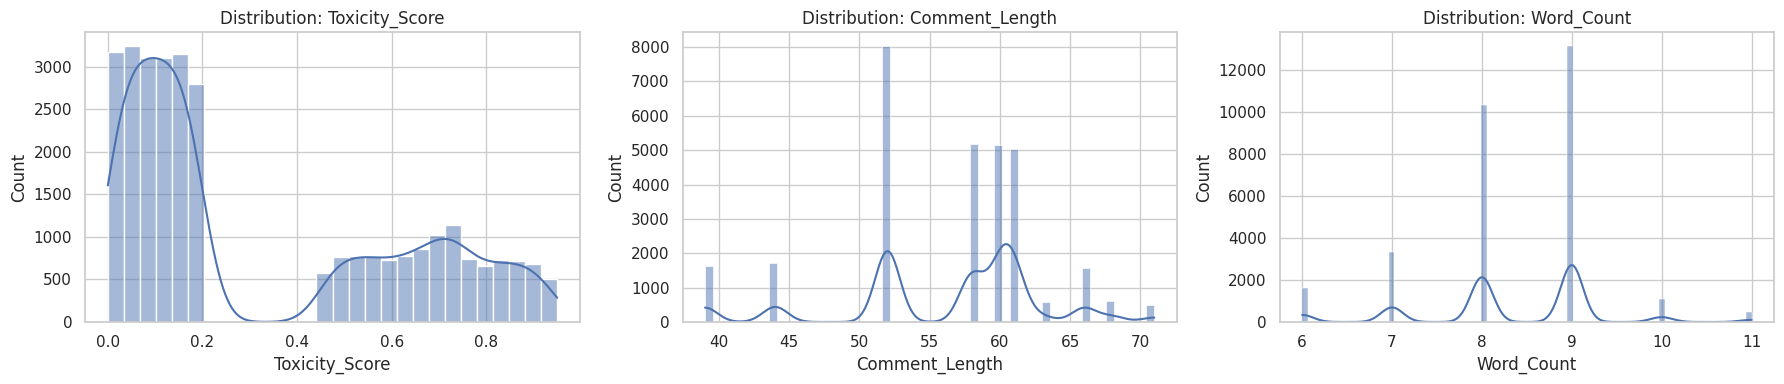

In [ ]:
# ─── Histogram + KDE ของ numeric columns ──────────────────────────────
num_plot_cols = ["Toxicity_Score", "Comment_Length", "Word_Count"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, num_plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

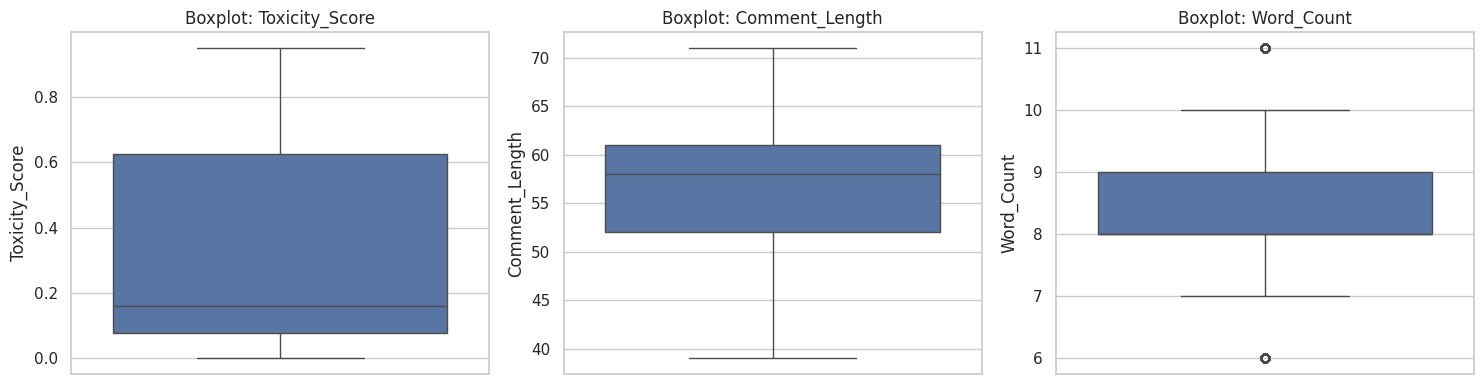

In [ ]:
# ─── Boxplot ของทุก numeric column: ดู outliers เบื้องต้น ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_plot_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

### 2.2 Univariate: สัดส่วนของแต่ละตัวแปร (Categorical)

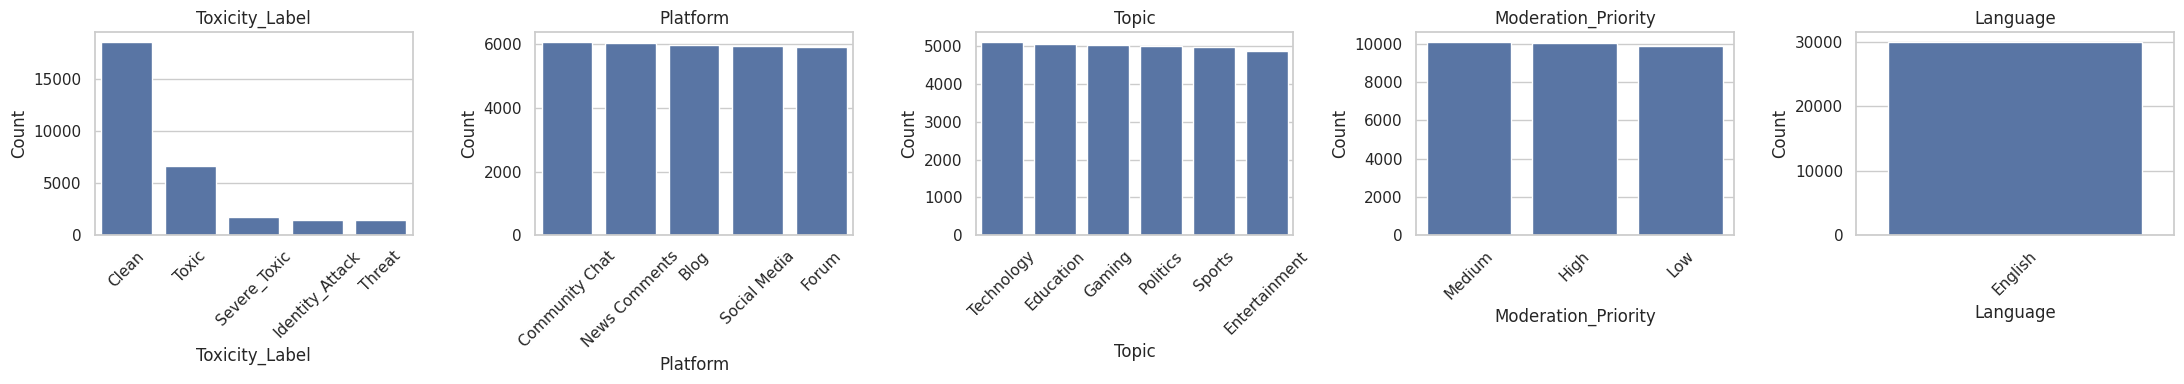

In [ ]:
# ─── Bar chart ของ categorical columns ────────────────────────────────
cat_plot_cols = ["Toxicity_Label", "Platform", "Topic", "Moderation_Priority", "Language"]

fig, axes = plt.subplots(1, len(cat_plot_cols), figsize=(22, 4))
for ax, col in zip(axes, cat_plot_cols):
    counts = df[col].value_counts(dropna=False)
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 2.3 Bivariate: ความสัมพันธ์ระหว่างตัวแปร Numeric (Correlation Heatmap)

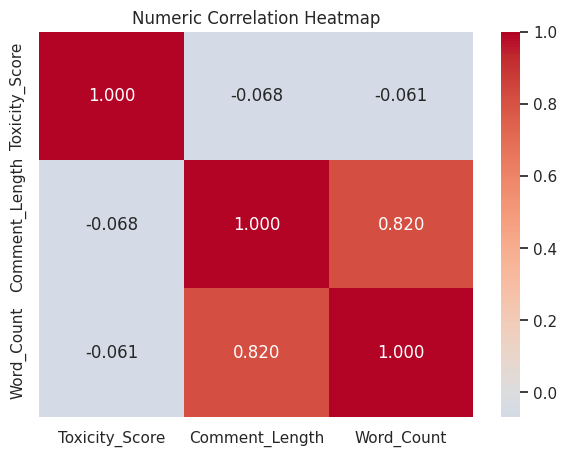

In [ ]:
# ─── Correlation Heatmap ───────────────────────────────────────────────
corr = df[num_plot_cols].corr(method="pearson")
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Numeric Correlation Heatmap")
plt.show()

### 2.4 Bivariate: Pairplot — มองหลายคู่พร้อมกัน

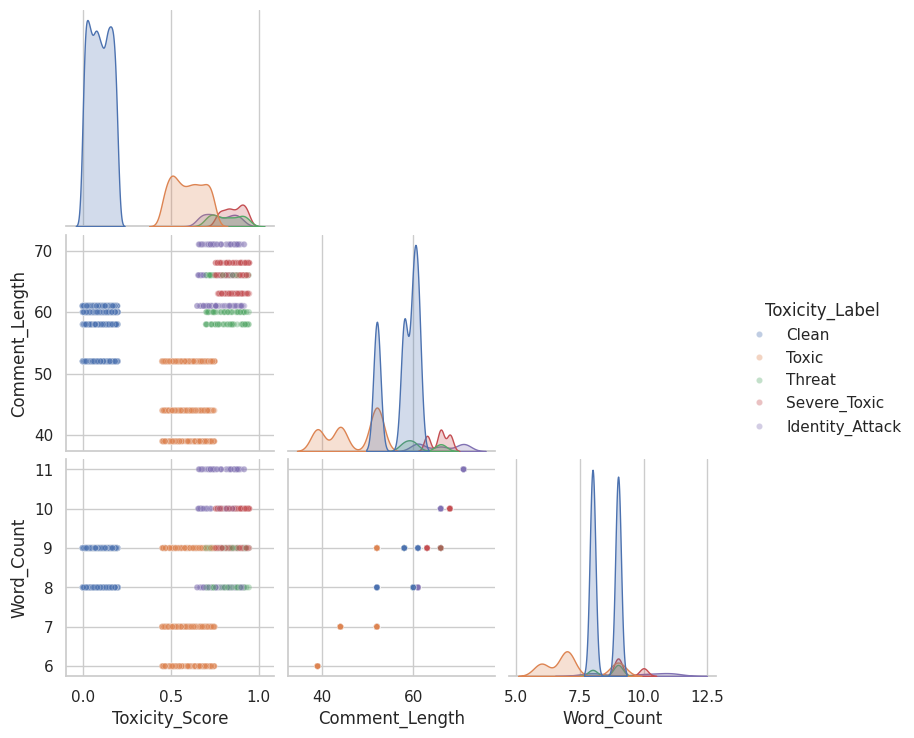

In [ ]:
# ─── Pairplot: numeric variables แยกสีตาม Toxicity Label ─────────────
pair_df = df[num_plot_cols + ["Toxicity_Label"]].dropna()

# ใช้ sample เพื่อให้กราฟอ่านง่ายและประมวลผลเร็ว
pair_sample = pair_df.sample(min(3000, len(pair_df)), random_state=42)

sns.pairplot(
    pair_sample,
    vars=num_plot_cols,
    hue="Toxicity_Label",
    corner=True,
    plot_kws={"alpha": 0.35, "s": 20}
)
plt.show()

### 2.5 Target-Focused: แต่ละ Feature สัมพันธ์กับ Target อย่างไร

ในโครงงานนี้ `Toxicity_Label` เป็น target สำหรับ Machine Learning ดังนั้น visualization จะดูทั้ง numeric features และ categorical features เทียบกับ label

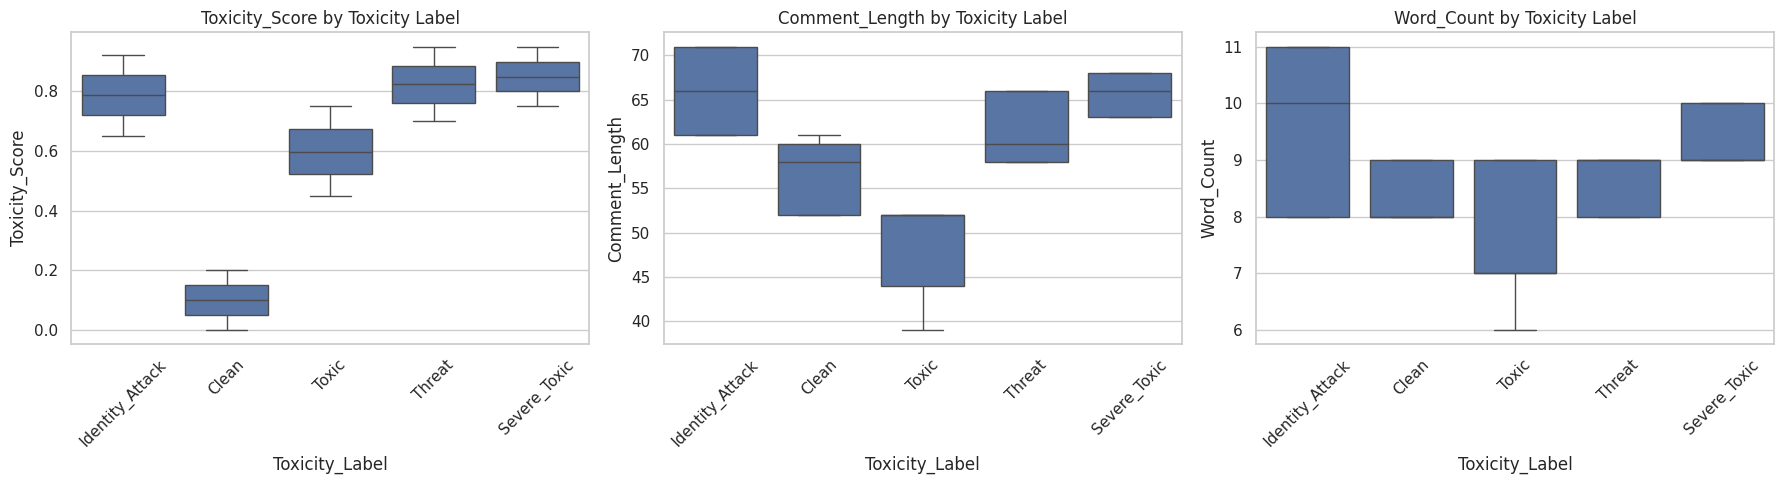

In [ ]:
# ─── Numeric feature vs Target: Boxplot แยกกลุ่ม ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_plot_cols):
    sns.boxplot(data=df, x="Toxicity_Label", y=col, ax=ax)
    ax.set_title(f"{col} by Toxicity Label")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

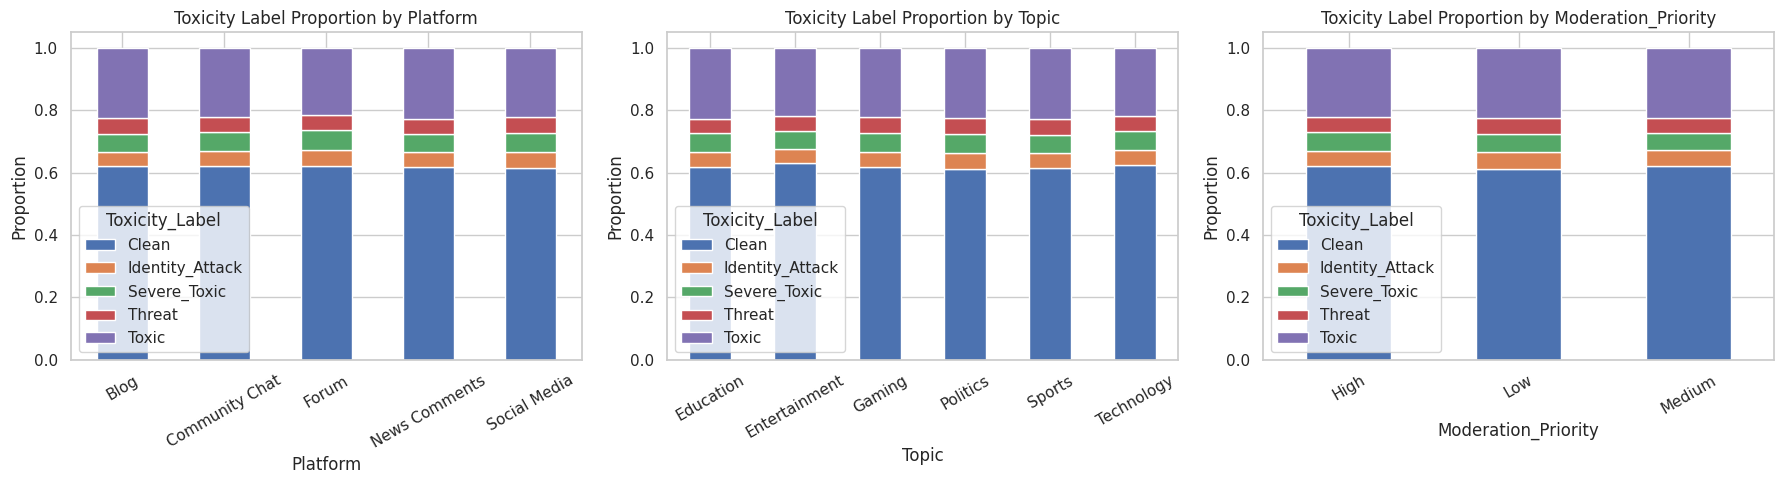

In [ ]:
# ─── Categorical feature vs Target: สัดส่วนของแต่ละ label ─────────────
target_cats = ["Platform", "Topic", "Moderation_Priority"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, target_cats):
    rate = pd.crosstab(df[col], df["Toxicity_Label"], normalize="index")
    rate.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(f"Toxicity Label Proportion by {col}")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 2.6 Multivariate: มองสามตัวแปรพร้อมกัน (FacetGrid)

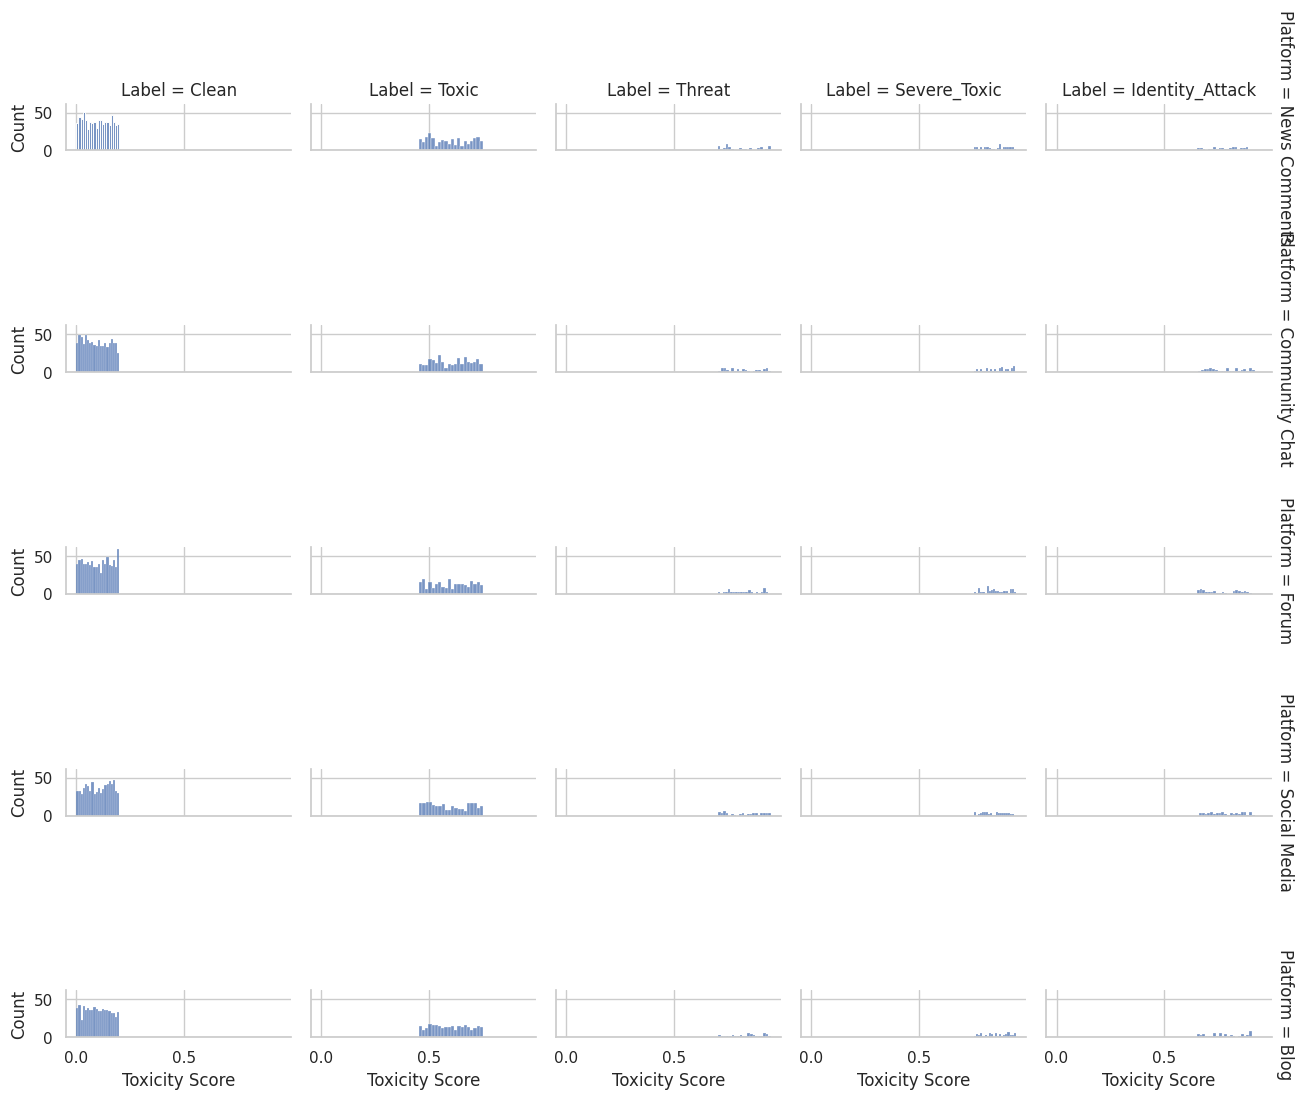

In [ ]:
# ─── FacetGrid: การกระจาย Toxicity Score แยกตาม Platform และ Label ───
g = sns.FacetGrid(
    df.sample(min(6000, len(df)), random_state=42),
    col="Toxicity_Label",
    row="Platform",
    height=2.2,
    aspect=1.2,
    margin_titles=True
)
g.map_dataframe(sns.histplot, x="Toxicity_Score", bins=20)
g.set_axis_labels("Toxicity Score", "Count")
g.set_titles(
    row_template="Platform = {row_name}",
    col_template="Label = {col_name}"
)
plt.tight_layout()
plt.show()

---
## Part 3: EDA เจาะลึก (Deep-Dive Analysis)

### 3.1 Outlier Detection ด้วย IQR Method

In [ ]:
# ─── หา Outliers ด้วย IQR Rule ────────────────────────────────────────
outlier_summary = []

for col in num_plot_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": int(mask.sum()),
        "Outlier %": mask.mean() * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.round(4))

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
0,Toxicity_Score,0.079,0.624,0.545,-0.7385,1.4415,0,0.0000
1,Comment_Length,52.000,61.000,9.000,38.5000,74.5000,0,0.0000
2,Word_Count,8.000,9.000,1.000,6.5000,10.5000,2116,7.0533


### 3.2 รูปร่างการกระจายตัว: Skewness, Kurtosis, QQ Plot, Normality Test

In [ ]:
# ─── Skewness และ Kurtosis ────────────────────────────────────────────
distribution_summary = pd.DataFrame({
    "Skewness": df[num_plot_cols].skew(),
    "Kurtosis": df[num_plot_cols].kurtosis()
})
display(distribution_summary.round(4))

,Skewness,Kurtosis
Toxicity_Score,0.6527,-1.1990
Comment_Length,-0.7390,0.4330
Word_Count,-0.4062,0.5546


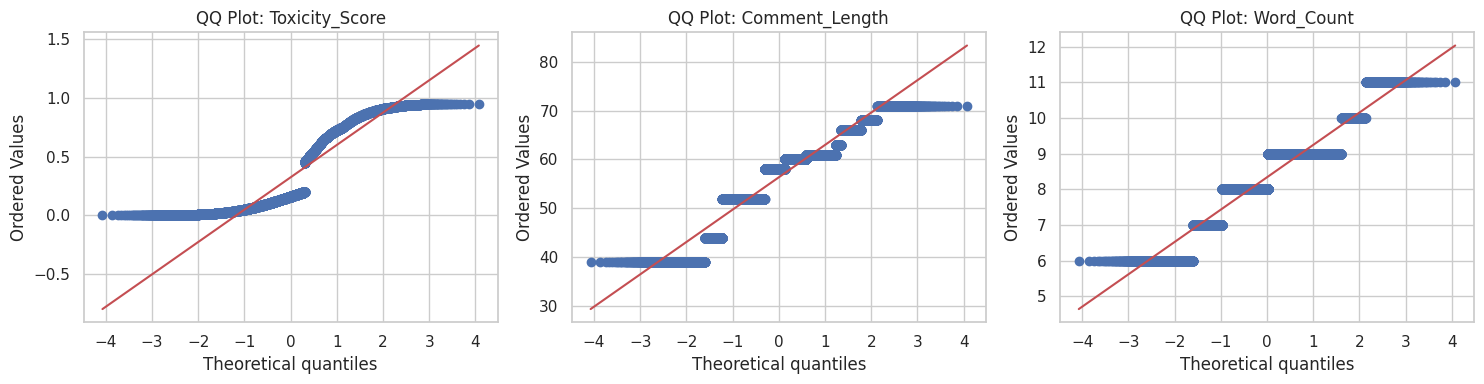

In [ ]:
# ─── QQ Plot: เทียบ distribution จริงกับ Normal Distribution ─────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_plot_cols):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"QQ Plot: {col}")
plt.tight_layout()
plt.show()

In [ ]:
# ─── Shapiro-Wilk Test: ใช้ sample ขนาดจำกัดเพื่อหลีกเลี่ยงข้อจำกัดของ test ─
shapiro_results = []
for col in num_plot_cols:
    values = df[col].dropna()
    sample = values.sample(min(5000, len(values)), random_state=42)
    stat, p = stats.shapiro(sample)
    shapiro_results.append({"Variable": col, "W": stat, "p-value": p})

display(pd.DataFrame(shapiro_results).round(6))
print("หมายเหตุ: เมื่อ sample ใหญ่ Shapiro-Wilk ไวต่อความเบี่ยงเบนเล็กน้อยจาก Normal มาก จึงต้องอ่านร่วมกับ histogram และ QQ plot")

,Variable,W,p-value
0,Toxicity_Score,0.818803,0.0
1,Comment_Length,0.897888,0.0
2,Word_Count,0.866029,0.0


หมายเหตุ: เมื่อ sample ใหญ่ Shapiro-Wilk ไวต่อความเบี่ยงเบนเล็กน้อยจาก Normal มาก จึงต้องอ่านร่วมกับ histogram และ QQ plot


### 3.3 Multicollinearity Check ด้วย VIF (เชื่อมกับ Week 10)

สำหรับโมเดลจะไม่ใช้ `Toxicity_Score` เป็น feature เพราะ score เป็นข้อมูลที่เกี่ยวข้องโดยตรงกับการกำหนดระดับ `Toxicity_Label` และอาจทำให้เกิด target leakage

In [ ]:
# ─── Variance Inflation Factor (VIF) ──────────────────────────────────
vif_data = df[["Comment_Length", "Word_Count"]].dropna().copy()
X_vif = sm.add_constant(vif_data)

vif_table = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
display(vif_table.round(4))

,Feature,VIF
0,const,1.0000
1,Comment_Length,3.0567
2,Word_Count,3.0567


### 3.4 สรุป EDA: ตัดสินใจ Preprocessing Strategy

**แนวทางสำหรับ Dataset นี้**
- `Toxicity_Score` ใช้สำหรับ EDA และ RQ1–RQ3 แต่ **ไม่ใช้เป็น X ในโมเดล** เพื่อป้องกัน target leakage
- `Comment_Length` และ `Word_Count` ใช้เป็น numeric features
- `Platform`, `Topic`, `Moderation_Priority` ใช้เป็น categorical features
- `Language` มีเพียงภาษาเดียวใน Dataset เดิม จึงไม่มีประโยชน์ต่อการจำแนกและจะไม่นำเข้าโมเดล
- `Comment_ID` เป็น identifier จึงไม่นำเข้าโมเดล
- Missing values จะจัดการภายใน Pipeline เพื่อป้องกัน data leakage
- Categorical variables จะใช้ One-Hot Encoding
- โมเดลที่อาศัยระยะทาง เช่น KNN จะใช้ StandardScaler กับ numeric features

---
## Part 4: ตั้งสมมติฐานจาก EDA และพิสูจน์ด้วย Hypothesis Testing

ส่วนนี้ยังตอบโจทย์เดิม แต่ปรับชนิด test ให้ตรงกับโครงสร้างข้อมูลจริงของโครงงาน

### 4.1 สมมติฐานที่ 1: Platform มีความสัมพันธ์กับ Toxicity Label หรือไม่? (Categorical vs Categorical → Chi-square)

In [ ]:
# ─── Chi-square Test of Independence: Platform vs Toxicity Label ──────
ct_platform = pd.crosstab(df["Platform"], df["Toxicity_Label"])
chi2, p, dof, expected = chi2_contingency(ct_platform)

print(f"Chi-square = {chi2:.4f}")
print(f"df = {dof}")
print(f"p-value = {p:.6g}")
print("เกณฑ์: ถ้า p-value < 0.05 ให้ปฏิเสธ H0 ว่าตัวแปรทั้งสองเป็นอิสระ")

Chi-square = 9.6611
df = 16
p-value = 0.883719
เกณฑ์: ถ้า p-value < 0.05 ให้ปฏิเสธ H0 ว่าตัวแปรทั้งสองเป็นอิสระ


### 4.2 สมมติฐานที่ 2: Topic มีความสัมพันธ์กับ Toxicity Label หรือไม่? (Categorical vs Categorical → Chi-square)

In [ ]:
# ─── Chi-square Test: Topic vs Toxicity Label ─────────────────────────
ct_topic = pd.crosstab(df["Topic"], df["Toxicity_Label"])
chi2, p, dof, expected = chi2_contingency(ct_topic)

print(f"Chi-square = {chi2:.4f}")
print(f"df = {dof}")
print(f"p-value = {p:.6g}")
print("เกณฑ์: ถ้า p-value < 0.05 ให้ปฏิเสธ H0 ว่าตัวแปรทั้งสองเป็นอิสระ")

Chi-square = 8.4538
df = 20
p-value = 0.988414
เกณฑ์: ถ้า p-value < 0.05 ให้ปฏิเสธ H0 ว่าตัวแปรทั้งสองเป็นอิสระ


### 4.3 สมมติฐานที่ 3: Comment Length แตกต่างกันระหว่าง Toxicity Label หรือไม่? (Numeric vs Multi-class Group → Kruskal-Wallis)

In [ ]:
# ─── Kruskal-Wallis Test ──────────────────────────────────────────────
groups = [
    group["Comment_Length"].dropna().values
    for _, group in df.groupby("Toxicity_Label", observed=True)
]

h_stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H = {h_stat:.4f}")
print(f"p-value = {p:.6g}")
print("เกณฑ์: ถ้า p-value < 0.05 แสดงว่ามีอย่างน้อยหนึ่งกลุ่มที่มีการกระจายแตกต่างจากกลุ่มอื่น")

Kruskal-Wallis H = 18437.5906
p-value = 0
เกณฑ์: ถ้า p-value < 0.05 แสดงว่ามีอย่างน้อยหนึ่งกลุ่มที่มีการกระจายแตกต่างจากกลุ่มอื่น


### 4.4 สรุปผล Hypothesis Testing ทั้งหมด

In [ ]:
# ─── ตารางสรุป Hypothesis Testing ─────────────────────────────────────
tests = []

chi2_p, p_platform, _, _ = chi2_contingency(pd.crosstab(df["Platform"], df["Toxicity_Label"]))
chi2_t, p_topic, _, _ = chi2_contingency(pd.crosstab(df["Topic"], df["Toxicity_Label"]))
h_kw, p_length = kruskal(*groups)

tests = pd.DataFrame({
    "Hypothesis": [
        "Platform vs Toxicity Label",
        "Topic vs Toxicity Label",
        "Comment Length vs Toxicity Label"
    ],
    "Test": ["Chi-square", "Chi-square", "Kruskal-Wallis"],
    "Statistic": [chi2_p, chi2_t, h_kw],
    "p-value": [p_platform, p_topic, p_length]
})
tests["Decision (alpha=0.05)"] = np.where(
    tests["p-value"] < 0.05, "Reject H0", "Fail to reject H0"
)
display(tests.round(6))

,Hypothesis,Test,Statistic,p-value,Decision (alpha=0.05)
0,Platform vs Toxicity Label,Chi-square,9.661051,0.883719,Fail to reject H0
1,Topic vs Toxicity Label,Chi-square,8.453776,0.988414,Fail to reject H0
2,Comment Length vs Toxicity Label,Kruskal-Wallis,18437.590607,0.000000,Reject H0


---
## Part 5: ตั้งโจทย์ (Problem Framing)

**Part นี้จะแปลง insight จาก Part 1–4 ให้เป็นโจทย์ Machine Learning ที่ชัดเจน** โดยต้องแยกให้ชัดระหว่างตัวแปรที่ใช้วิเคราะห์ กับตัวแปรที่อนุญาตให้โมเดลใช้

### 5.1 กำหนด Task Type จากลักษณะของ Target (Y)

| ลักษณะของ Y | Task Type | วิธีที่ใช้ได้ |
|---|---|---|
| Continuous | Regression | SLR/MLR, Polynomial Regression |
| Binary | Binary Classification | Logistic, LDA, QDA, Naive Bayes, KNN |
| **Multi-class (>2 กลุ่ม)** | **Multiclass Classification** | **Multinomial Logistic, LDA, QDA, Naive Bayes, KNN** |
| Count | Count Regression | Poisson / GLM |

**สำหรับโครงงานนี้:** `Toxicity_Label` มี 5 กลุ่ม (`Clean`, `Toxic`, `Severe_Toxic`, `Identity_Attack`, `Threat`) → **Multiclass Classification**

**สำคัญ:** `Toxicity_Score` จะไม่ถูกใช้เป็น X เพราะเป็นตัวแปรที่ใกล้ชิดกับการกำหนด `Toxicity_Label` โดยตรง

In [ ]:
# ─── กำหนด X และ Y อย่างชัดเจน ────────────────────────────────────────
feature_cols_num = ["Comment_Length", "Word_Count"]
feature_cols_cat = ["Platform", "Topic", "Moderation_Priority"]
target_col = "Toxicity_Label"

print(f"Target (Y): {target_col} — Multiclass Classification")
print(f"Numeric Features (X): {feature_cols_num}")
print(f"Categorical Features (X): {feature_cols_cat}")
print("Excluded: Toxicity_Score (เสี่ยง target leakage), Comment_ID (identifier), Language (มีเพียง category เดียว)")

Target (Y): Toxicity_Label — Multiclass Classification
Numeric Features (X): ['Comment_Length', 'Word_Count']
Categorical Features (X): ['Platform', 'Topic', 'Moderation_Priority']
Excluded: Toxicity_Score (เสี่ยง target leakage), Comment_ID (identifier), Language (มีเพียง category เดียว)


### 5.2 เลือก Success Metric ให้ตรงกับคำถามทางงานวิเคราะห์

เนื่องจาก target มีหลาย class และ class มีขนาดไม่เท่ากัน จึงไม่ควรดู Accuracy เพียงตัวเดียว

| สถานการณ์ | Metric ที่เหมาะ | เหตุผล |
|---|---|---|
| ต้องการภาพรวม | Accuracy | บอกสัดส่วนที่ทำนายถูกทั้งหมด |
| Class มีสัดส่วนต่างกัน | **Macro F1** | ให้น้ำหนักแต่ละ class เท่ากัน |
| ต้องการดู ranking ของหลาย class | Multiclass AUC | ประเมินการแยก class จาก probability |
| ต้องการดูราย class | Precision / Recall / F1 | เห็นจุดแข็งและข้อผิดพลาดของแต่ละ class |

**สำหรับโครงงานนี้:** ใช้ **Macro F1 เป็น metric หลัก**, และรายงาน Accuracy + Multiclass AUC ประกอบ

In [ ]:
# ─── ตรวจสอบความสมดุลของ target ก่อนเลือก metric ─────────────────────
target_dist = df[target_col].value_counts(normalize=True).round(4)
display(target_dist.rename("Proportion").to_frame())

print("ใช้ Macro F1 เป็น metric หลัก เพราะต้องการให้ทั้ง 5 class มีความสำคัญเท่า ๆ กัน")

,Proportion
Toxicity_Label,
Clean,0.6193
Toxic,0.2231
Severe_Toxic,0.0600
Identity_Attack,0.0489
Threat,0.0486


ใช้ Macro F1 เป็น metric หลัก เพราะต้องการให้ทั้ง 5 class มีความสำคัญเท่า ๆ กัน


### 5.3 Train/Test Split (เตรียมไว้สำหรับ Part 6)

Split แบบ stratified เพื่อรักษาสัดส่วนของ `Toxicity_Label` ใน train และ test และให้ preprocessing อยู่ใน Pipeline

In [ ]:
# ─── เตรียม X และ y ก่อน Split ────────────────────────────────────────
X = df[feature_cols_num + feature_cols_cat].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} แถว")
print(f"Test:  {X_test.shape[0]} แถว")
print("\nTarget proportion — Train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTarget proportion — Test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 24000 แถว
Test:  6000 แถว

Target proportion — Train:
Toxicity_Label
Clean              0.619
Toxic              0.223
Severe_Toxic       0.060
Identity_Attack    0.049
Threat             0.049
Name: proportion, dtype: float64

Target proportion — Test:
Toxicity_Label
Clean              0.619
Toxic              0.223
Severe_Toxic       0.060
Identity_Attack    0.049
Threat             0.049
Name: proportion, dtype: float64


---
## Part 6: เลือกโมเดลและวิธีที่เหมาะสม (Model & Method Selection)

**โจทย์นี้เป็น Multiclass Classification** ดังนั้นจะเปรียบเทียบวิธีที่เหมาะกับ classification หลายกลุ่มอย่างเป็นระบบ และใช้ Cross-Validation ก่อนประเมิน Test Set ครั้งสุดท้าย

### 6.1 กรอบการตัดสินใจ: ตารางสรุปทุกวิธีในวิชานี้

| Task Type | วิธี | Assumption / จุดเด่น | เมื่อไหร่ควรใช้ |
|---|---|---|---|
| **Multiclass Classification** | Multinomial Logistic Regression | baseline, ตีความง่าย | เริ่มต้นเป็น baseline |
| | LDA | class distributions มีโครงสร้างร่วมกัน | ใช้เมื่อ separation มีลักษณะค่อนข้างเป็นเส้น |
| | QDA | covariance ต่างกันระหว่าง class | ใช้เมื่อ boundary มีความซับซ้อนขึ้น |
| | Naive Bayes | สมมติ features มีความเป็นอิสระ | baseline ที่เร็วและง่าย |
| | KNN | ไม่กำหนดรูปแบบ boundary | ใช้เมื่อรูปแบบการแยกกลุ่มไม่เป็นเส้นตรง |

**หลักปฏิบัติ:** เริ่มจาก baseline ที่ง่ายก่อน แล้วเปรียบเทียบด้วย metric และ Cross-Validation เดียวกัน

In [ ]:
# ─── Preprocessing: Impute + One-Hot Encoding + Scaling ───────────────
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, feature_cols_num),
    ("cat", categorical_transformer, feature_cols_cat)
])

# ─── Fit ทุก Classifier ที่เหมาะกับ Multiclass Classification ────────
models = {
    "Multinomial Logistic Regression": LogisticRegression(
        max_iter=2000, multi_class="multinomial"
    ),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# Fit เพื่อยืนยันว่า pipeline ของแต่ละวิธีทำงานกับข้อมูลจริงได้
# การเลือกโมเดลอย่างเป็นทางการจะทำด้วย Cross-Validation ในขั้นตอน 6.2
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    pipe.fit(X_train, y_train)
    print(f"{name}: fitted successfully")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multinomial Logistic Regression: fitted successfully
LDA: fitted successfully
QDA: fitted successfully
Naive Bayes: fitted successfully
KNN (k=5): fitted successfully


### 6.2 เปรียบเทียบอย่างเป็นธรรมด้วย k-Fold Cross-Validation (Week 14)

ใช้ **5-Fold Stratified CV บน Training Set** เพื่อประเมินความเสถียรของโมเดลก่อนเลือก final model โดยใช้ **Macro F1** เป็น metric หลัก

In [ ]:
# ─── 5-Fold Stratified CV บน Training Set ────────────────────────────
# วัตถุประสงค์: ประเมินแต่ละโมเดลด้วยหลาย fold แทนการวัดครั้งเดียว
# ลด variance ของ estimate และให้ SE เพื่อใช้ One-SE Rule ต่อ
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=skf,
        scoring="f1_macro"
    )

    cv_results.append({
        "Model": name,
        "CV Macro F1 (mean)": scores.mean(),
        "CV Macro F1 (SE)": scores.std(ddof=1) / np.sqrt(5)
    })

cv_df = pd.DataFrame(cv_results).sort_values(
    "CV Macro F1 (mean)", ascending=False
)

display(cv_df.round(4))

# ─── One-Standard-Error Rule (Week 14) ───────────────────────────────
best_row = cv_df.iloc[0]
threshold = best_row["CV Macro F1 (mean)"] - best_row["CV Macro F1 (SE)"]
within_1se = cv_df[
    cv_df["CV Macro F1 (mean)"] >= threshold
]

print(f"Best model by CV Macro F1: {best_row['Model']}")
print(f"Best CV Macro F1 = {best_row['CV Macro F1 (mean)']:.4f}")
print(f"1-SE threshold = {threshold:.4f}")
print("\nModels within 1-SE of the best:")
print(within_1se["Model"].tolist())

# ในกรณีนี้ใช้โมเดลที่มี CV Macro F1 สูงสุดเป็น final model
# และจะไม่ดูผล Test Set จนกว่าจะถึง Part 6.3
final_model_name = best_row["Model"]

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,Model,CV Macro F1 (mean),CV Macro F1 (SE)
4,KNN (k=5),0.7626,0.0038
0,Multinomial Logistic Regression,0.6006,0.0038
3,Naive Bayes,0.5729,0.0045
2,QDA,0.5532,0.0072
1,LDA,0.4512,0.0019


Best model by CV Macro F1: KNN (k=5)
Best CV Macro F1 = 0.7626
1-SE threshold = 0.7588

Models within 1-SE of the best:
['KNN (k=5)']


### 6.3 Final Evaluation: ประเมินโมเดลสุดท้ายบน Test Set (ครั้งเดียว!)

**กฎสำคัญ:** Test Set ใช้สำหรับรายงานผลสุดท้ายหลังจากเลือกโมเดลด้วย Cross-Validation แล้ว เพื่อหลีกเลี่ยง optimistic bias

=== Final Model: KNN (k=5) ===
Accuracy: 0.9377
Macro F1: 0.7762
Macro AUC (OvR): 0.9377

=== Classification Report ===
                 precision    recall  f1-score   support

          Clean       0.94      1.00      0.97      3716
Identity_Attack       0.96      0.87      0.92       293
   Severe_Toxic       0.80      0.82      0.81       360
         Threat       0.37      0.13      0.19       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           0.94      6000
      macro avg       0.81      0.76      0.78      6000
   weighted avg       0.92      0.94      0.93      6000



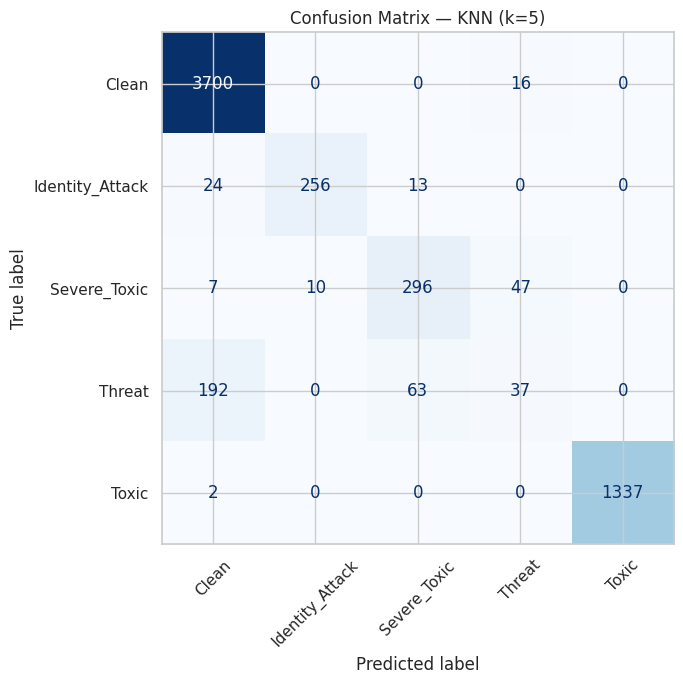

In [ ]:
# ─── Refit โมเดลที่เลือกบน Training Set ทั้งหมด แล้ว evaluate บน Test ─
final_model = models[final_model_name]

final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", final_model)
])

final_pipe.fit(X_train, y_train)

y_pred_final = final_pipe.predict(X_test)
y_proba_final = final_pipe.predict_proba(X_test)

print(f"=== Final Model: {final_model_name} ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_final, average='macro'):.4f}")

final_auc = roc_auc_score(
    y_test,
    y_proba_final,
    multi_class="ovr",
    average="macro",
    labels=final_pipe.named_steps["clf"].classes_
)
print(f"Macro AUC (OvR): {final_auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_final))

# ─── Confusion Matrix Visualization ──────────────────────────────────
labels = final_pipe.named_steps["clf"].classes_
cm = confusion_matrix(y_test, y_pred_final, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.show()

---
## สรุปทั้งหมด: จาก EDA สู่ Model Selection

| Part | สิ่งที่ทำ | ผลลัพธ์ที่ได้ |
|---|---|---|
| 1. Data Understanding | ตรวจ shape, dtypes, missing, duplicates, cardinality | เข้าใจโครงสร้าง Dataset 30,000 รายการและปัญหาข้อมูล |
| 2. Visualization | Univariate, bivariate, target-focused, multivariate plots | เห็น distribution, correlation และ pattern ของ toxicity |
| 3. EDA เจาะลึก | IQR, skewness/kurtosis, QQ plot, Shapiro, VIF | ใช้หลักฐานกำหนด preprocessing และระวัง multicollinearity |
| 4. Hypothesis Testing | Chi-square และ Kruskal-Wallis | ตรวจว่าความแตกต่าง/ความสัมพันธ์ที่เห็นจาก EDA มีหลักฐานทางสถิติหรือไม่ |
| 5. Problem Framing | กำหนด X, Y, task type, metric, train/test split | โจทย์ชัดเจน: **Multiclass Classification**, Macro F1 เป็น metric หลัก |
| 6. Model Selection | Fit 5 methods, 5-Fold CV, final test evaluation | เปรียบเทียบโมเดลอย่างเป็นระบบและรายงานผล final model |

### ข้อสรุปสำคัญของโครงงาน
- Dataset เดิมมี **30,000 comments**
- `Toxicity_Label` มี **5 classes**
- `Toxicity_Score` ใช้สำหรับ EDA และ RQ เดิม แต่ **ไม่ใช้เป็น feature ในโมเดล** เพื่อหลีกเลี่ยง target leakage
- โมเดลใช้ `Comment_Length`, `Word_Count`, `Platform`, `Topic` และ `Moderation_Priority`
- ใช้ **Macro F1** เป็น metric หลัก และ Accuracy / Macro AUC เป็น metrics ประกอบ
- Final model ต้องเลือกจาก Cross-Validation ก่อน แล้วจึง evaluate บน Test Set

## คำถามทบทวน (Reflection Questions)

1. เพราะเหตุใด `Toxicity_Score` จึงไม่ควรนำไปเป็น feature เพื่อทำนาย `Toxicity_Label` แม้ว่าจะทำให้โมเดลทำนายได้ง่ายขึ้น?
2. ถ้า Accuracy สูง แต่ Macro F1 ต่ำ เราควรตรวจสอบอะไรใน confusion matrix และ class distribution?
3. เพราะเหตุใดเราจึงใช้ Stratified K-Fold เมื่อ `Toxicity_Label` มีหลาย class?
4. ถ้า `Platform` มี p-value < 0.05 จาก Chi-square Test เราสรุปได้หรือไม่ว่า Platform เป็นสาเหตุให้ความคิดเห็นมีความเป็นพิษ? เพราะเหตุใด?
5. ถ้าโมเดล KNN มีผลดีขึ้นหลัง StandardScaler อธิบายได้อย่างไร?